In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ==========================================
# STEP 2 - Load Required Datasets
# ==========================================

import pandas as pd

http = pd.read_csv("/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/http.csv", nrows=100000)
logon = pd.read_csv("/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/logon.csv", nrows=100000)
device = pd.read_csv("/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/device.csv", nrows=100000)
file = pd.read_csv("/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/file.csv", nrows=100000)
email = pd.read_csv("/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/email.csv", nrows=100000)
insiders = pd.read_csv("/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv")

print("Datasets Loaded Successfully\n")

print("HTTP    :", http.shape)
print("LOGON   :", logon.shape)
print("DEVICE  :", device.shape)
print("FILE    :", file.shape)
print("EMAIL   :", email.shape)
print("INSIDERS:", insiders.shape)

Datasets Loaded Successfully

HTTP    : (100000, 6)
LOGON   : (100000, 5)
DEVICE  : (100000, 5)
FILE    : (100000, 6)
EMAIL   : (100000, 11)
INSIDERS: (191, 6)


In [4]:
# ==========================================================
# DATA CLEANING
# ==========================================================

import pandas as pd

# ---------------- HTTP ----------------
http = http.drop_duplicates()
http = http.dropna(subset=["user", "date"])

# ---------------- LOGON ----------------
logon = logon.drop_duplicates()
logon = logon.dropna(subset=["user", "date"])

# ---------------- DEVICE ----------------
device = device.drop_duplicates()
device = device.dropna(subset=["user", "date"])

# ---------------- FILE ----------------
file = file.drop_duplicates()
file = file.dropna(subset=["user", "date"])

# ---------------- EMAIL ----------------
email = email.drop_duplicates()
email = email.dropna(subset=["user", "date"])

# Fill attachment null values
if "attachments" in email.columns:
    email["attachments"] = email["attachments"].fillna(0)

print("="*60)
print("DATA CLEANING COMPLETED")
print("="*60)

print("\nHTTP   :", http.shape)
print("LOGON  :", logon.shape)
print("DEVICE :", device.shape)
print("FILE   :", file.shape)
print("EMAIL  :", email.shape)
print("INSIDERS :", insiders.shape)

DATA CLEANING COMPLETED

HTTP   : (100000, 6)
LOGON  : (100000, 5)
DEVICE : (100000, 5)
FILE   : (100000, 6)
EMAIL  : (100000, 11)
INSIDERS : (191, 6)


In [5]:
print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# -----------------------------
# HTTP
# -----------------------------
http["date"] = pd.to_datetime(http["date"])
http = http.drop_duplicates()
http = http.fillna(0)

# -----------------------------
# LOGON
# -----------------------------
logon["date"] = pd.to_datetime(logon["date"])
logon = logon.drop_duplicates()
logon = logon.fillna(0)

# -----------------------------
# DEVICE
# -----------------------------
device["date"] = pd.to_datetime(device["date"])
device = device.drop_duplicates()
device = device.fillna(0)

# -----------------------------
# FILE
# -----------------------------
file["date"] = pd.to_datetime(file["date"])
file = file.drop_duplicates()
file = file.fillna(0)

# -----------------------------
# EMAIL
# -----------------------------
email["date"] = pd.to_datetime(email["date"])
email = email.drop_duplicates()
email = email.fillna(0)

print("\nData Preprocessing Completed\n")

print("HTTP   :", http.shape)
print("LOGON  :", logon.shape)
print("DEVICE :", device.shape)
print("FILE   :", file.shape)
print("EMAIL  :", email.shape)
print("INSIDERS :", insiders.shape)

DATA PREPROCESSING

Data Preprocessing Completed

HTTP   : (100000, 6)
LOGON  : (100000, 5)
DEVICE : (100000, 5)
FILE   : (100000, 6)
EMAIL  : (100000, 11)
INSIDERS : (191, 6)


In [6]:
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

# HTTP
http["date"] = pd.to_datetime(http["date"])
http["activity_date"] = http["date"].dt.date
http["hour"] = http["date"].dt.hour
http["after_hours"] = ((http["hour"] < 8) | (http["hour"] > 18)).astype(int)
http["weekend"] = (http["date"].dt.dayofweek >= 5).astype(int)

http_daily = (
    http.groupby(["user", "activity_date"])
    .agg(
        http_count=("id", "count"),
        unique_url=("url", "nunique"),
        after_hours_activity=("after_hours", "sum"),
        weekend_activity=("weekend", "sum")
    )
    .reset_index()
)

# LOGON
logon["date"] = pd.to_datetime(logon["date"])
logon["activity_date"] = logon["date"].dt.date

logon_daily = (
    logon.groupby(["user", "activity_date"])
    .agg(
        logon_count=("id", "count"),
        unique_pc=("pc", "nunique")
    )
    .reset_index()
)

# DEVICE
device["date"] = pd.to_datetime(device["date"])
device["activity_date"] = device["date"].dt.date

device_daily = (
    device.groupby(["user", "activity_date"])
    .agg(
        device_count=("id", "count")
    )
    .reset_index()
)

# FILE
file["date"] = pd.to_datetime(file["date"])
file["activity_date"] = file["date"].dt.date

file_daily = (
    file.groupby(["user", "activity_date"])
    .agg(
        file_count=("id", "count"),
        unique_files=("filename", "nunique")
    )
    .reset_index()
)

# EMAIL
email["date"] = pd.to_datetime(email["date"])
email["activity_date"] = email["date"].dt.date

email_daily = (
    email.groupby(["user", "activity_date"])
    .agg(
        email_count=("id", "count"),
        unique_receivers=("to", "nunique"),
        total_attachment=("attachments", "sum")
    )
    .reset_index()
)

# Merge
daily = http_daily.merge(logon_daily, on=["user","activity_date"], how="outer")
daily = daily.merge(device_daily, on=["user","activity_date"], how="outer")
daily = daily.merge(file_daily, on=["user","activity_date"], how="outer")
daily = daily.merge(email_daily, on=["user","activity_date"], how="outer")

daily.fillna(0, inplace=True)

print("\nDaily Feature Dataset Shape :", daily.shape)
print(daily.head())

FEATURE ENGINEERING

Daily Feature Dataset Shape : (45995, 14)
      user activity_date  http_count  unique_url  after_hours_activity  \
0  AAE0190    2010-01-04       143.0        54.0                   0.0   
1  AAE0190    2010-01-05         0.0         0.0                   0.0   
2  AAE0190    2010-01-06         0.0         0.0                   0.0   
3  AAE0190    2010-01-07         0.0         0.0                   0.0   
4  AAE0190    2010-01-08         0.0         0.0                   0.0   

   weekend_activity  logon_count  unique_pc  device_count  file_count  \
0               0.0          2.0        1.0           0.0         0.0   
1               0.0          2.0        1.0           0.0         0.0   
2               0.0          2.0        1.0           0.0         0.0   
3               0.0          2.0        1.0           0.0         0.0   
4               0.0          2.0        1.0           0.0         0.0   

   unique_files  email_count  unique_receivers  total

In [10]:
print("="*60)
print("MODEL TRAINING")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Create Labels
daily["label"] = daily["user"].isin(insiders["user"]).astype(int)

print("\nLabel Distribution")
print(daily["label"].value_counts())

# Features
feature_columns = [
    "http_count",
    "unique_url",
    "after_hours_activity",
    "weekend_activity",
    "logon_count",
    "unique_pc",
    "device_count",
    "file_count",
    "unique_files",
    "email_count",
    "unique_receivers",
    "total_attachment"
]

X = daily[feature_columns]
y = daily["label"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))

# Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("\nRandom Forest Trained Successfully")

# Save Model
joblib.dump(model, "random_forest_model.pkl")
print("Model Saved Successfully")

# Prediction
y_pred = model.predict(X_test)

print("\nAccuracy")
print(round(accuracy_score(y_test, y_pred),4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nLabel Definition")
print("0 -> Normal User")
print("1 -> Insider User")

MODEL TRAINING

Label Distribution
label
0    41976
1     4019
Name: count, dtype: int64

Training Samples : 36796
Testing Samples : 9199

Random Forest Trained Successfully
Model Saved Successfully

Accuracy
0.8628

Confusion Matrix
[[7449  946]
 [ 316  488]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      8395
           1       0.34      0.61      0.44       804

    accuracy                           0.86      9199
   macro avg       0.65      0.75      0.68      9199
weighted avg       0.91      0.86      0.88      9199


Label Definition
0 -> Normal User
1 -> Insider User


FEATURE IMPORTANCE
                 Feature  Importance
6           device_count    0.339928
4            logon_count    0.141545
8           unique_files    0.109560
7             file_count    0.109263
5              unique_pc    0.107903
11      total_attachment    0.073881
10      unique_receivers    0.044283
9            email_count    0.039078
1             unique_url    0.015188
0             http_count    0.009690
2   after_hours_activity    0.008669
3       weekend_activity    0.001012


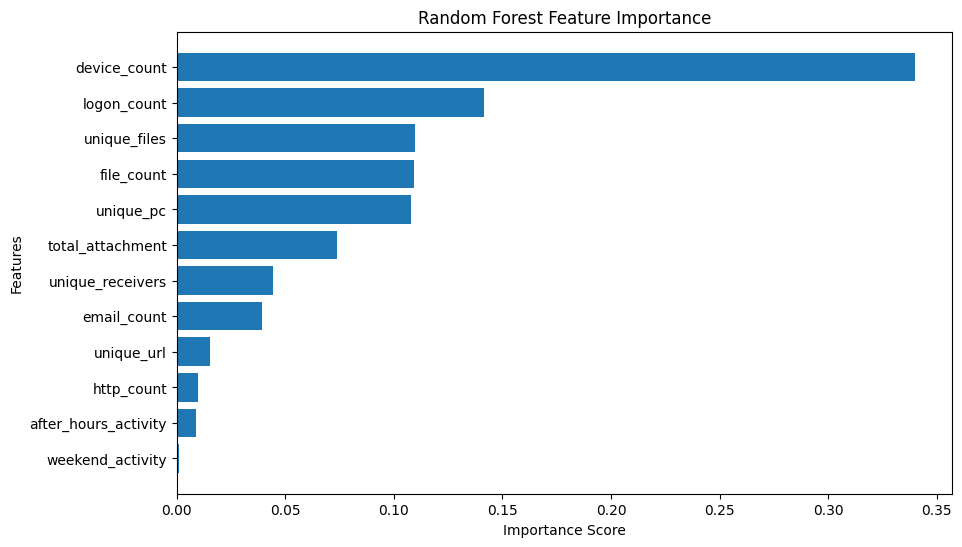


Feature Importance Saved Successfully


In [9]:
print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

importance.to_csv("feature_importance.csv", index=False)

print("\nFeature Importance Saved Successfully")